In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
DIR = os.path.join(os.getcwd(), "data")

In [4]:
data = {}
for filename in os.listdir(DIR):
    if filename.endswith("_csv_CLEAN.csv"):
        filepath = os.path.join(DIR, f"{filename}")
        response = pd.read_csv(filepath, index_col="Date", parse_dates=True)
        data[filename] = response

        
FEATURE_COLS = [
    'rsi_14', "return_1day", "return_5day", "return_10day", "return_20day", "sma_5", "sma_10", 
    "close_ratio_amv_10", "sma_20", "close_ratio_amv_20", 
    "close_ratio_amv_5", 'macd_line', 'bb_width', 'bb_pct_b', 
    'volatility_10_day', 'volatility_20_day', 
    'volume_1day', 'volume_20_sma', 'volume_normalize_ratio',
]

# for stock, dataframe in data.items():
    # print(stock)
    # print(dataframe.head(5))


#VFV Example
vfv_df = data["VFV_TO_csv_CLEAN.csv"]
vfv_df = vfv_df.dropna(subset=["future_return"])
X = vfv_df[FEATURE_COLS]
y_logistical_reg = vfv_df["target"]
y_linear_reg = vfv_df["future_return"]

#Creating the train and test
X_train, X_test, y_train_log, y_test_log, y_train_lin, y_test_lin = train_test_split(
    X, 
    y_logistical_reg, 
    y_linear_reg, 
    test_size=0.2, 
    shuffle=False 
)


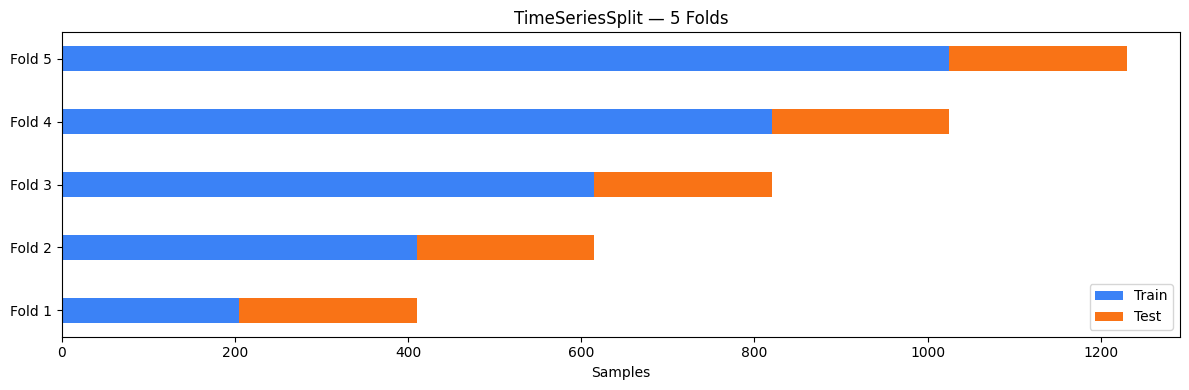

In [5]:
#Time Series Cross Validation
time_series_cross_validation = TimeSeriesSplit(n_splits=5)

# Visualize the folds
figure, axis = plt.subplots(figsize=(12, 4))
for fold_i, (train_idx, test_idx) in enumerate(time_series_cross_validation.split(X)):
    axis.barh(fold_i, len(train_idx), left=0, height=0.4, color="#3b82f6", label="Train" if fold_i == 0 else "")
    axis.barh(fold_i, len(test_idx), left=len(train_idx), height=0.4, color="#f97316", label="Test" if fold_i == 0 else "")
axis.set_yticks(range(5))
axis.set_yticklabels([f"Fold {i+1}" for i in range(5)])
axis.set_xlabel("Samples")
axis.set_title("TimeSeriesSplit — 5 Folds")
axis.legend()
plt.tight_layout()
plt.show()

In [6]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num_cleaner", StandardScaler(), FEATURE_COLS)
    ]
)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
#Pipeline for Direction (1 or 0)
log_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression(max_iter=5000))
])
#Pipeline for Predicated Values 
lin_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("linear_model", LinearRegression())
])
#Pipeline for Direction + L1 (Lasso)
log_l1_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression(l1_ratio=1, solver="saga", max_iter=5000))
])
#Pipeline for Direction + L2 (Ridge)
log_l2_pipeline = Pipeline([
    ("cleaning_steps", preprocessor),
    ("logistic_model", LogisticRegression(l1_ratio=0, max_iter=5000))
])

# print("Training Logistic Model")
# log_pipeline.fit(X_train, y_train_log)

# print("Training Linear Model")
# lin_pipeline.fit(X_train, y_train_lin)


In [ ]:


#Accuracy for target
# log_predictions = log_pipeline.predict(X_test)
# log_accuracy = accuracy_score(y_test_log, log_predictions)
# print("\n--- Logistic Regression Results ---")
# print(f"Accuracy: {log_accuracy * 100:.2f}%")

# #Accuracy for future_return
# lin_predictions = lin_pipeline.predict(X_test)
# lin_mse = mean_squared_error(y_test_lin, lin_predictions)
# lin_r2 = r2_score(y_test_lin, lin_predictions)
# print("\n--- Linear Regression Results ---")
# print(f"Mean Squared Error: {lin_mse:.6f}")
# print(f"R-Squared (R2): {lin_r2:.4f}")


--- Logistic Regression Results ---
Accuracy: 60.98%

--- Linear Regression Results ---
Mean Squared Error: 0.001014 (Lower is better)
R-Squared (R2): -0.9640 (1.0 is perfect)


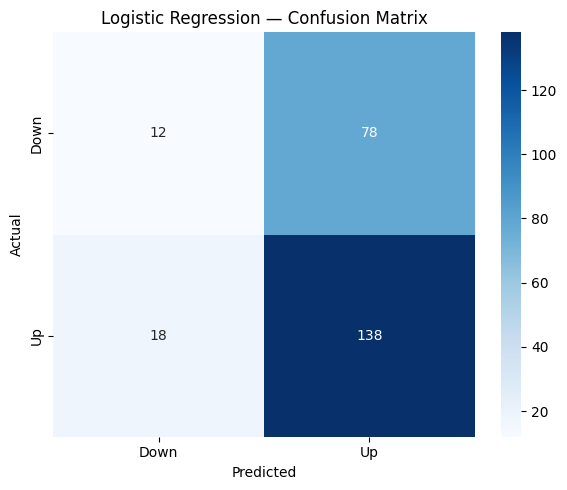

In [ ]:
# Confusion matrix
# cm = confusion_matrix(y_test_log, log_predictions)
# fig, ax = plt.subplots(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
#             xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
# ax.set_xlabel("Predicted")
# ax.set_ylabel("Actual")
# ax.set_title("Logistic Regression — Confusion Matrix")
# plt.tight_layout()
# plt.show()

In [7]:
#Implementing TimeSeriesSplit
models = {
    "Logistic (baseline)": log_pipeline,
    "Logistic + L1 (Lasso)": log_l1_pipeline,
    "Logistic + L2 (Ridge)": log_l2_pipeline,
}
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y_logistical_reg, cv=time_series_cross_validation, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:30s}  Accuracy: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")

Logistic (baseline)             Accuracy: 0.4956 ± 0.0842  (folds: [0.5366 0.4927 0.3366 0.5317 0.5805])
Logistic + L1 (Lasso)           Accuracy: 0.4927 ± 0.0912  (folds: [0.522  0.478  0.3317 0.522  0.6098])
Logistic + L2 (Ridge)           Accuracy: 0.4956 ± 0.0842  (folds: [0.5366 0.4927 0.3366 0.5317 0.5805])


In [8]:
param_grid = {'logistic_model__C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.5]}
best_models = {}

# 4. Loop through each model and run the Grid Search
for name, pipe in models.items():
    print(f"--- Running Grid Search for {name} ---")
    
    grid = GridSearchCV(
        estimator=pipe, 
        param_grid=param_grid, 
        cv=time_series_cross_validation, 
        scoring="accuracy", 
        n_jobs=-1
    )
    grid.fit(X_train, y_train_log)
    best_models[name] = grid
    
    
    # Print out the grades
    print(f"Best C value: {grid.best_params_['logistic_model__C']}")
    print(f"Best CV Accuracy: {grid.best_score_ * 100:.2f}%\n")
print(best_models)

--- Running Grid Search for Logistic (baseline) ---


Best C value: 0.1
Best CV Accuracy: 47.80%

--- Running Grid Search for Logistic + L1 (Lasso) ---
Best C value: 0.01
Best CV Accuracy: 57.56%

--- Running Grid Search for Logistic + L2 (Ridge) ---
Best C value: 0.1
Best CV Accuracy: 47.80%

{'Logistic (baseline)': GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('cleaning_steps',
                                        ColumnTransformer(transformers=[('num_cleaner',
                                                                         StandardScaler(),
                                                                         ['rsi_14',
                                                                          'return_1day',
                                                                          'return_5day',
                                                                          'return_10day',
                                                         

{'Logistic (baseline)': array([0.53658537, 0.49268293, 0.33658537, 0.53170732, 0.5804878 ]), 'Logistic + L1 (Lasso)': array([0.52195122, 0.47804878, 0.33170732, 0.52195122, 0.6097561 ]), 'Logistic + L2 (Ridge)': array([0.53658537, 0.49268293, 0.33658537, 0.53170732, 0.5804878 ]), 'Tuned L1 (Lasso)': array([0.40853659, 0.57926829, 0.62195122, 0.72560976, 0.54268293]), 'Tuned L2 (Ridge)': array([0.46341463, 0.59756098, 0.47560976, 0.31097561, 0.54268293])}


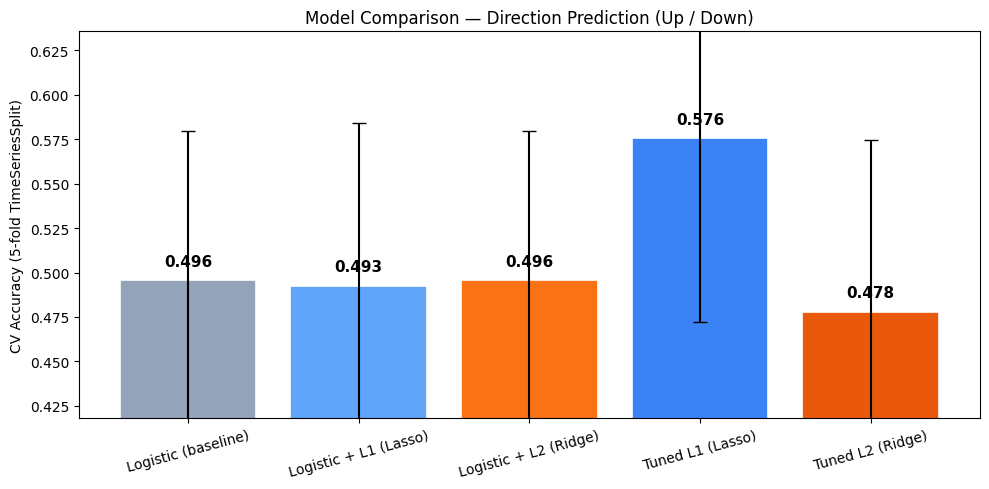

In [10]:
""" 
Logistic + L1 (Lasso)" (Using the default C=1.0)
Logistic + L2 (Ridge)" (Using the default C=1.0)
Tuned L1 (Lasso)" (Using the absolute best C from the grid search)
Tuned L2 (Ridge)" (Using the absolute best C from the grid search)
"""

cv_results["Tuned L1 (Lasso)"] = cross_val_score(
    best_models["Logistic + L1 (Lasso)"].best_estimator_, 
    X_train, y_train_log,
    cv=time_series_cross_validation, 
    scoring="accuracy"
)

cv_results["Tuned L2 (Ridge)"] = cross_val_score(
    best_models["Logistic + L2 (Ridge)"].best_estimator_, 
    X_train, y_train_log,
    cv=time_series_cross_validation, 
    scoring="accuracy"
)

print(cv_results)

figure, axis = plt.subplots(figsize=(10, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]

colors = ["#94a3b8", "#60a5fa", "#f97316", "#3b82f6", "#ea580c"]
bars = axis.bar(names, means, yerr=stds, capsize=5, color=colors[:len(names)], edgecolor="white", linewidth=1.2)
axis.set_ylabel("CV Accuracy (5-fold TimeSeriesSplit)")
axis.set_title("Model Comparison — Direction Prediction (Up / Down)")

# Dynamically set the Y-axis limits so the differences are easier to see
axis.set_ylim(min(means) - 0.06, max(means) + 0.06)
# Add the exact accuracy numbers on top of each bar
for bar, m in zip(bars, means):
    axis.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f"{m:.3f}", ha="center", fontsize=11, fontweight="bold")

axis.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [16]:
# Final evaluation on the holdout set (the last 20% from your original split)
print("=" * 60)
print("FINAL HOLDOUT RESULTS (last 20%)")
print("=" * 60)

# Baseline
log_pipeline.fit(X_train, y_train_log)
base_preds = log_pipeline.predict(X_test)
base_acc = accuracy_score(y_test_log, base_preds)
print(f"\nBaseline (no regularization):  {base_acc:.4f}")

# Tuned L1 and L2
for label, grid in best_models.items():
    pipe = grid.best_estimator_
    pipe.fit(X_train, y_train_log)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test_log, preds)
    print(f"\nTuned {label}  (C={grid.best_params_['logistic_model__C']})")
    print(f"  Accuracy: {acc:.4f}")
    print(classification_report(y_test_log, preds, target_names=["Down", "Up"]))

FINAL HOLDOUT RESULTS (last 20%)

Baseline (no regularization):  0.6098

Tuned Logistic (baseline)  (C=0.1)
  Accuracy: 0.5650
              precision    recall  f1-score   support

        Down       0.19      0.06      0.09        90
          Up       0.61      0.86      0.71       156

    accuracy                           0.57       246
   macro avg       0.40      0.46      0.40       246
weighted avg       0.46      0.57      0.48       246


Tuned Logistic + L1 (Lasso)  (C=0.01)
  Accuracy: 0.6341
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        90
          Up       0.63      1.00      0.78       156

    accuracy                           0.63       246
   macro avg       0.32      0.50      0.39       246
weighted avg       0.40      0.63      0.49       246


Tuned Logistic + L2 (Ridge)  (C=0.1)
  Accuracy: 0.5650
              precision    recall  f1-score   support

        Down       0.19      0.06      0.09      

/Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/linusgao/Documents/Projects/2026/stock-predictor-1/server/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted